### C3M9: Helpful Data Visualizations for Data Cleaning and EDA

Body Brain Weights of Mammals. We will look at this data on the log scale.

In [1]:
#get data
BodyBrain <- read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/BodyBrainMammals.csv", header = T)
head(BodyBrain)


,Species,BodyWt,BrainWt,SlowWave,Dreaming,TotalSleep,LifeSpan,Gestation,Predation,SleepExposure,OverallDanger,LnBodyWt,LnBrainWt
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>
1,Africanelephant,6654.000,5712.0,NA,NA,3.3,38.6,645,3,5,3,8.80297346,8.650325
2,Africangiantpouchedrat,1.000,6.6,6.3,2.0,8.3,4.5,42,3,1,3,0.00000000,1.887070
3,ArcticFox,3.385,44.5,NA,NA,12.5,14.0,60,1,1,1,1.21935391,3.795489
4,Arcticgroundsquirrel,0.920,5.7,NA,NA,16.5,NA,25,5,2,3,-0.08338161,1.740466
5,Asianelephant,2547.000,4603.0,2.1,1.8,3.9,69.0,624,3,5,4,7.84267148,8.434464
6,Baboon,10.550,179.5,9.1,0.7,9.8,27.0,180,4,4,4,2.35612586,5.190175


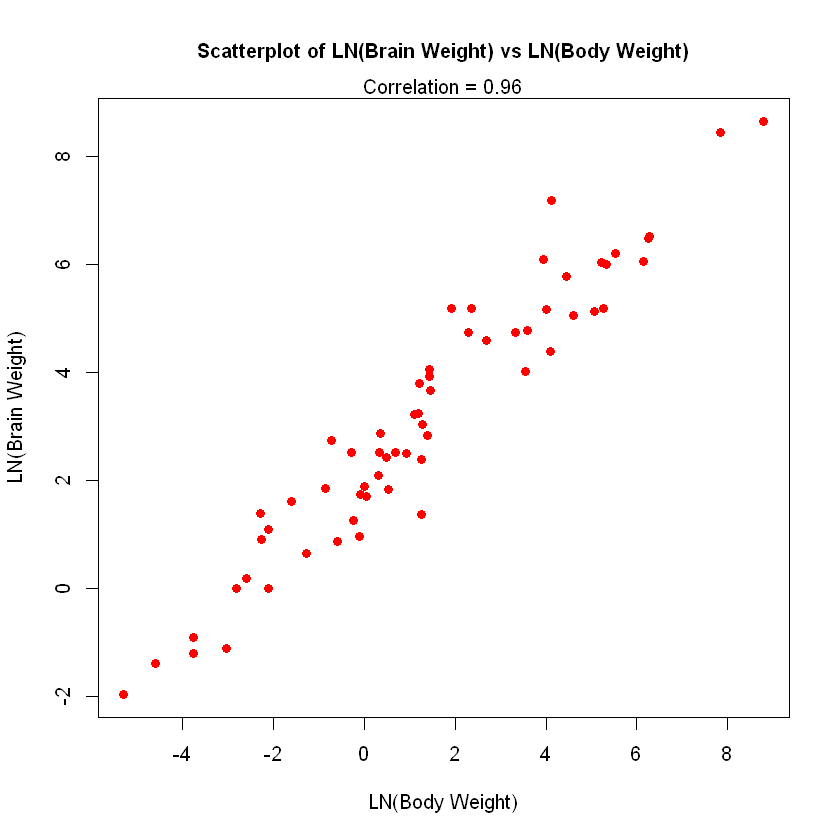

In [3]:
#Remind ourselves of the log of both variables:

plot(BodyBrain$LnBodyWt, BodyBrain$LnBrainWt, 
     pch = 19, 
     xlab = "LN(Body Weight)", 
     ylab = "LN(Brain Weight)", 
     cex.main = 1, 
     main = "Scatterplot of LN(Brain Weight) vs LN(Body Weight)", 
     col = 'red')
mtext(paste("Correlation =", round(cor(BodyBrain$LnBodyWt, BodyBrain$LnBrainWt), 2)))

REGRESSION - to fit a regression model, we use the lm() function in R (this stands for Linear Models).

In [4]:
#Fit a linear model and save to object lm1
lm1 <- lm(LnBrainWt ~ LnBodyWt, data = BodyBrain)
names(lm1)
lm1$coefficients

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "xlevels"       "call"          "terms"         "model"

(Intercept)    LnBodyWt 
  2.1347887   0.7516859

Let's create a fitted line plot with the predicted regression line included

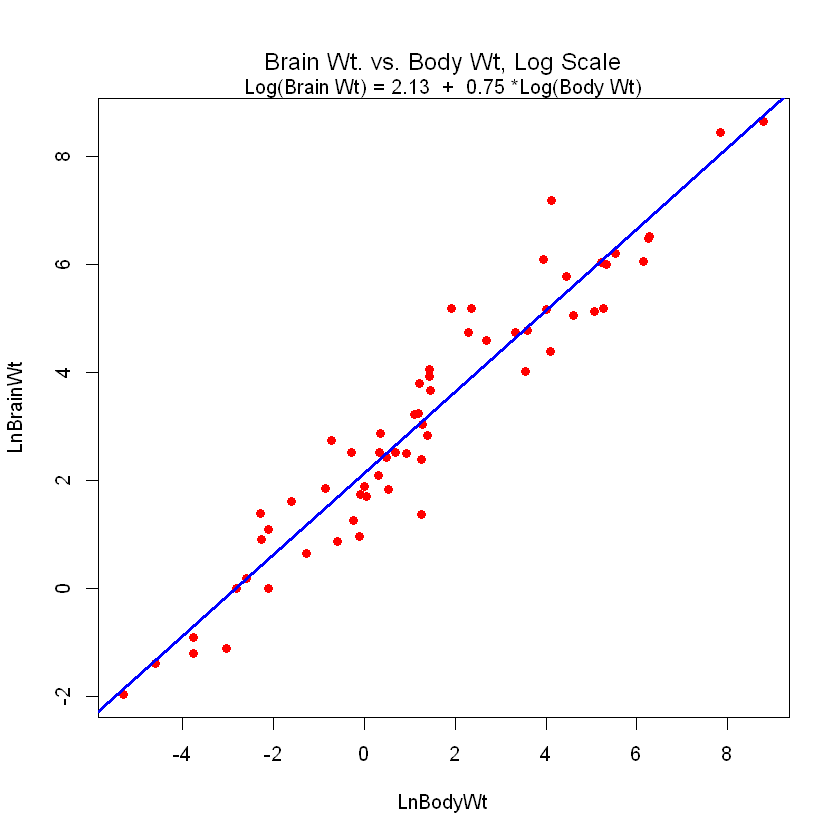

In [5]:
plot(LnBrainWt ~ LnBodyWt, 
     data = BodyBrain, 
     col = 'red', 
     pch = 19)

abline(lm1$coef, col = "blue", lwd = 3)
mtext("Brain Wt. vs. Body Wt, Log Scale", line = 1, cex = 1.2)
mtext(paste("Log(Brain Wt) =", round(lm1$coef[1], 2)," + ", round(lm1$coef[2], 2), "*Log(Body Wt)"), line = 0)


What if I want to get the predicted log brain weight of a new animal with log body weight 7.5?

In [6]:
# predicted log brain weight
new_data <- data.frame(LnBodyWt = c(7.5, 0))

round(predict(lm1, newdata = new_data), 2)

1    2 
7.77 2.13

Let's look at the actual output from our regression analysis.

In [7]:
#Minimal information
lm1


Call:
lm(formula = LnBrainWt ~ LnBodyWt, data = BodyBrain)

Coefficients:
(Intercept)     LnBodyWt  
     2.1348       0.7517  


In [8]:
#Use the summary function
summary(lm1)


Call:
lm(formula = LnBrainWt ~ LnBodyWt, data = BodyBrain)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.71550 -0.49228 -0.06162  0.43597  1.94829 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.13479    0.09604   22.23   <2e-16 ***
LnBodyWt     0.75169    0.02846   26.41   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.6943 on 60 degrees of freedom
Multiple R-squared:  0.9208,	Adjusted R-squared:  0.9195 
F-statistic: 697.4 on 1 and 60 DF,  p-value: < 2.2e-16


Note that Muliple R-squared is just the square of the correlation

In [9]:
round(cor(BodyBrain$LnBrainWt, BodyBrain$LnBodyWt), 4)
round(cor(BodyBrain$LnBrainWt, BodyBrain$LnBodyWt)^2, 4)

[1] 0.9596

[1] 0.9208

Height, Volume, Diameter of Cherry Trees (last time)

,Diameter,Height,Volume
,<dbl>,<int>,<dbl>
1,8.3,70,10.3
2,8.6,65,10.3
3,8.8,63,10.2
4,10.5,72,16.4
5,10.7,81,18.8
6,10.8,83,19.7


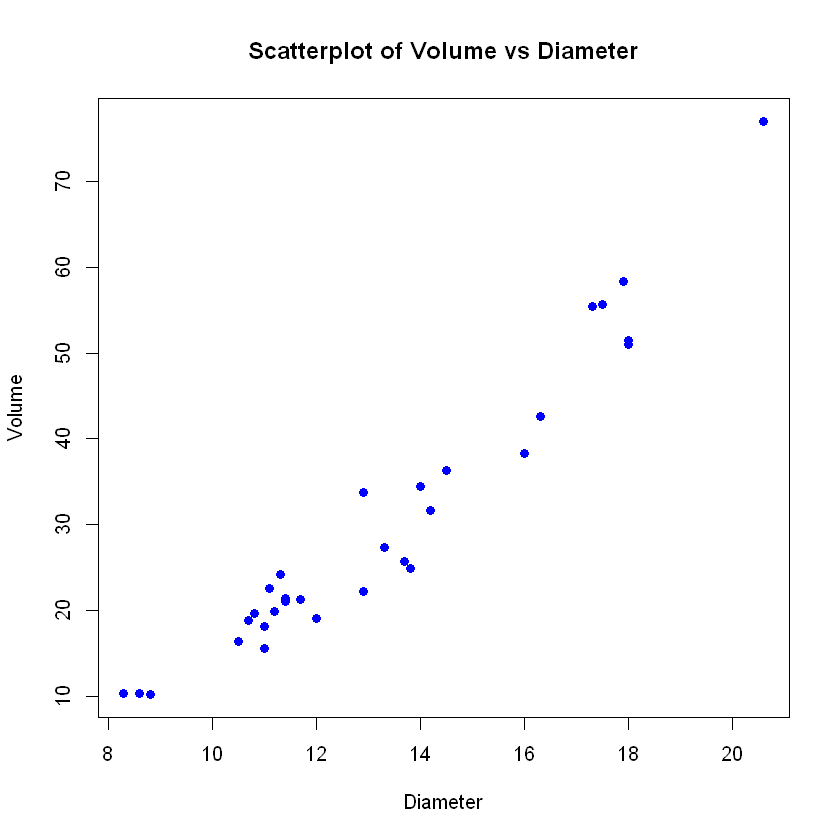

In [10]:
#Get the data
Cherry <-  read.csv("https://raw.githubusercontent.com/jreuning/YSE_EDA_data/refs/heads/main/Cherry.Trees.csv", header = T)
head(Cherry)
plot(Cherry$Diameter, Cherry$Volume, 
     pch = 19, 
     xlab = "Diameter", 
     ylab = "Volume", 
     main = "Scatterplot of Volume vs Diameter", 
     col = 'blue')

In [11]:
#fit regression model
lm2 <- lm(Volume ~ Diameter, data = Cherry)
summary(lm2)


Call:
lm(formula = Volume ~ Diameter, data = Cherry)

Residuals:
   Min     1Q Median     3Q    Max 
-8.065 -3.107  0.152  3.495  9.587 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -36.9435     3.3651  -10.98 7.62e-12 ***
Diameter      5.0659     0.2474   20.48  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.252 on 29 degrees of freedom
Multiple R-squared:  0.9353,	Adjusted R-squared:  0.9331 
F-statistic: 419.4 on 1 and 29 DF,  p-value: < 2.2e-16


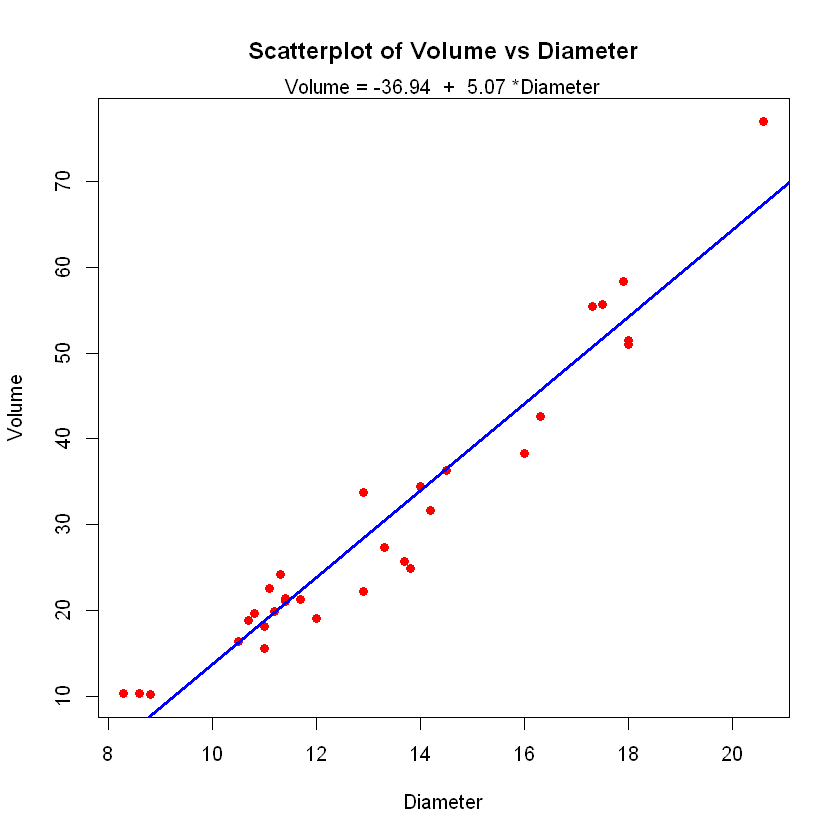

In [12]:
plot(Volume ~ Diameter, data = Cherry,
     pch = 19, 
     xlab = "Diameter", 
     ylab = "Volume", 
     main = "Scatterplot of Volume vs Diameter", 
     col = 'red')

abline(lm2$coef, col = "blue", lwd = 3)
mtext(paste("Volume =", round(lm2$coef[1], 2)," + ", round(lm2$coef[2], 2), "*Diameter"), line = 0)

Let's look at Volume as predicted by Height


Call:
lm(formula = Volume ~ Height, data = Cherry)

Residuals:
    Min      1Q  Median      3Q     Max 
-21.274  -9.894  -2.894  12.068  29.852 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -87.1236    29.2731  -2.976 0.005835 ** 
Height        1.5433     0.3839   4.021 0.000378 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 13.4 on 29 degrees of freedom
Multiple R-squared:  0.3579,	Adjusted R-squared:  0.3358 
F-statistic: 16.16 on 1 and 29 DF,  p-value: 0.0003784


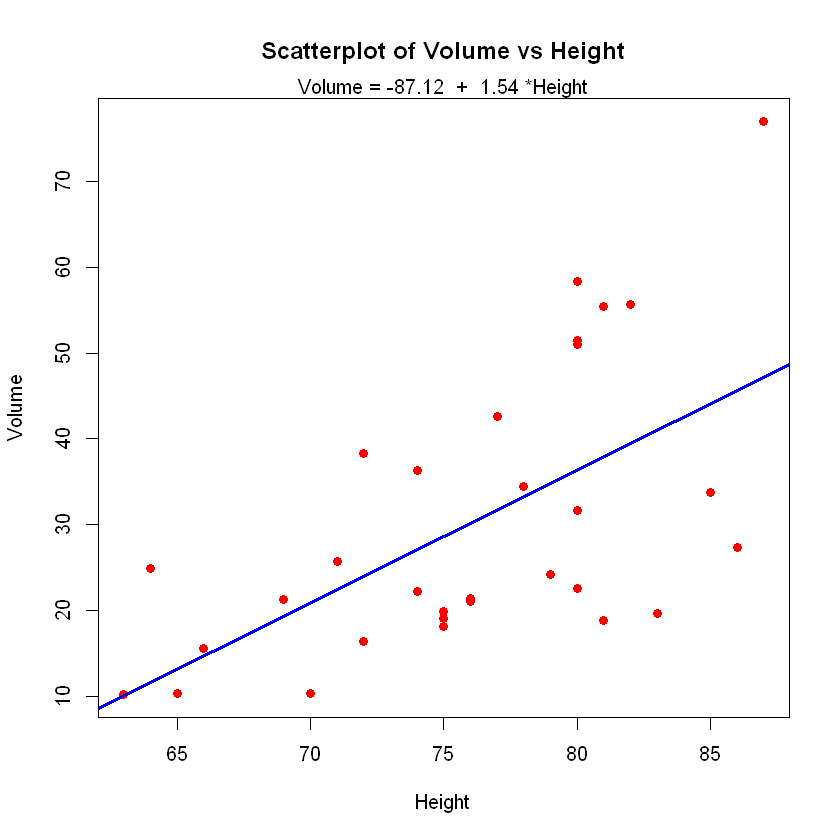

In [14]:
#Fit a regression model
lm3 <- lm(Volume ~ Height, data = Cherry)
summary(lm3)
#Make a fitted line plot
plot(Volume ~ Height, data = Cherry,
     pch = 19, 
     xlab = "Height", 
     ylab = "Volume", 
     main = "Scatterplot of Volume vs Height", 
     col = 'red')

abline(lm3$coef, col = "blue", lwd = 3)
mtext(paste("Volume =", round(lm3$coef[1], 2)," + ", round(lm3$coef[2], 2), "*Height"), line = 0)